You are given a 2D integer array squares. Each squares[i] = [xi, yi, li] represents the coordinates of the bottom-left point and the side length of a square parallel to the x-axis.

Find the minimum y-coordinate value of a horizontal line such that the total area covered by squares above the line equals the total area covered by squares below the line.

Answers within 10-5 of the actual answer will be accepted.

Note: Squares may overlap. Overlapping areas should be counted only once in this version.

 

Example 1:

Input: squares = [[0,0,1],[2,2,1]]

Output: 1.00000

Explanation:

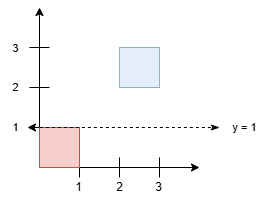

Any horizontal line between y = 1 and y = 2 results in an equal split, with 1 square unit above and 1 square unit below. The minimum y-value is 1.

Example 2:

Input: squares = [[0,0,2],[1,1,1]]

Output: 1.00000

Explanation:

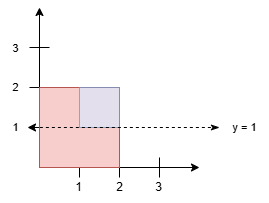

Since the blue square overlaps with the red square, it will not be counted again. Thus, the line y = 1 splits the squares into two equal parts.

 

Constraints:

    1 <= squares.length <= 5 * 104
    squares[i] = [xi, yi, li]
    squares[i].length == 3
    0 <= xi, yi <= 109
    1 <= li <= 109
    The total area of all the squares will not exceed 1015.



In [ ]:
class SegmentTree:
    def __init__(self, xs: List[int]):
        self.xs = xs
        self.n = len(xs) - 1
        self.count = [0] * (4 * self.n)
        self.covered = [0] * (4 * self.n)

    def update(self, qleft, qright, qval, left, right, pos):
        if self.xs[right + 1] <= qleft or self.xs[left] >= qright:
            return
        if qleft <= self.xs[left] and self.xs[right + 1] <= qright:
            self.count[pos] += qval
        else:
            mid = (left + right) // 2
            self.update(qleft, qright, qval, left, mid, pos * 2 + 1)
            self.update(qleft, qright, qval, mid + 1, right, pos * 2 + 2)

        if self.count[pos] > 0:
            self.covered[pos] = self.xs[right + 1] - self.xs[left]
        else:
            if left == right:
                self.covered[pos] = 0
            else:
                self.covered[pos] = (
                    self.covered[pos * 2 + 1] + self.covered[pos * 2 + 2]
                )

    def query(self):
        return self.covered[0]


class Solution:
    def separateSquares(self, squares: List[List[int]]) -> float:
        events = []
        xs_set = set()
        for x, y, l in squares:
            events.append((y, 1, x, x + l))
            events.append((y + l, -1, x, x + l))
            xs_set.update([x, x + l])
        xs = sorted(xs_set)

        seg_tree = SegmentTree(xs)
        events.sort()

        psum = []
        widths = []
        total_area = 0.0
        prev_y = events[0][0]

        # scan: calculate total area and record intermediate states
        for y, delta, xl, xr in events:
            length = seg_tree.query()
            total_area += length * (y - prev_y)
            seg_tree.update(xl, xr, delta, 0, seg_tree.n - 1, 0)
            # record prefix sums and widths
            psum.append(total_area)
            widths.append(seg_tree.query())
            prev_y = y

        # calculate the target area (half rounded up)
        target = (total_area + 1) // 2
        # find the first position greater than or equal to target using binary search
        i = bisect.bisect_left(psum, target) - 1
        # get the corresponding area, width, and height
        area = psum[i]
        width = widths[i]
        height = events[i][0]

        return height + (total_area - area * 2) / (width * 2.0)